# Grandcanonical Moves for Monte Carlo

Here we'll look at a 2D example of Monte Carlo in the $\mu$VT ensemble, using a canonical move with Metropolis acceptance criterion and a grand canonical move to add or remove particles based on the chemical potential $\mu$. 

In [27]:
import numpy as np
import os
import random 
import time
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation
from matplotlib.patches import Rectangle

In [28]:
# From prior HW and examples 
def minimum_image(r, L):
    """
    Calculate minimum image convention for distances in the box
    args:
        r: array of any shape
        L: side length of cubic box
    returns:
        array of the same shape as r,
        the minimum image of r
    """
    return r - L*np.round(r / L)

def cubic_lattice(tiling, L):
    """
    Initialize particles in a cubic box on a cubic lattice in 2D
    args:
        tiling (int): determines number of coordinates,
        by tiling^2
        L (float): side length of simulation box
    returns:
        array of shape (tiling^2, 2): coordinates on a cubic lattice,
        all between -0.5L and 0.5L
    """
    coord = []
    for x in range(tiling):
        for y in range(tiling):
                coord.append([x,y])
    coord = np.array(coord)/float(tiling)
    coord -= 0.5
    return coord*L

Now we need to be able to calculate the total energy of a configuration:

In [186]:
# Note: this is not the most elegant way to implement this, 
# most simulation packages would separate out the LJ calculations into
# a separate function. We also hardcoded epsilon=sigma=1. 
def tot_pe(pos, rc,L):
    """
    Measures total potential energy
    args:
        pos (array):  particle positions
        rc (float): cutoff distance for interaction
        i.e. if dist[i,j] > rc, the pair potential between
        i and j will be 0
    returns:
        float: total potential energy
    """
    table = pos[:,np.newaxis,:] - pos[np.newaxis,:,:]
    displacements = minimum_image(table, L)
    r = np.linalg.norm(displacements, axis=-1)
    r[np.diag_indices(len(r))] = np.inf
    v = 4*r**(-6)*(r**(-6) - 1)
    v[r >= rc] = 0 
    return 0.5*np.sum(v)

We could use the above function for our Metropolis algorithm, but that would be really inefficient - because we would recompute all energies, we really only need to calculate changes associated with moving one partice *i*: 

In [187]:
def pe(i, pos, lbox, rc):
    """ Calculate the total force and total potential energy
    associated with particle i (force and pe)
    
    force should be the total force on particle i from
    all other particles.
    
    pe should be the sum of all terms in the total potential
    that changes with the position of particle i.
    The sum of pe should be two times the total potential energy.
    
    Args:
    i (int): particle index
    pos (np.array): particle positions, shape (natom, ndim)
    lbox (float): cubic box side length
    rc (float): potential cutoff radius
    Return:
    float:  pe - potential energy 
    """
    drij = minimum_image(pos[i] - pos[np.newaxis, :], lbox)
    rij = np.linalg.norm(drij, axis=-1)
    r2i = rij[(0 < rij) & (rij < rc)]**(-2)
    r6i = r2i**3
    #print(i,pos[i], drij,pos,4*r6i*(r6i-1),(4*r6i*(r6i-1)).sum())
    pot = (4*r6i*(r6i-1)).sum()
    return pot

In [198]:
# Note: this will be different in HW due to PL testing. 
def mc_move(pos, lbox, rc, beta,tau):
    """ Perform one Monte Carlo move
    
    Args:
    pos (np.array): particle positions, shape (natom, ndim)
    lbox (float): cubic box side length
    rc (float): potential cutoff radius
    beta (float): inverse temperature
    tau (float): Gaussian width for trial move stepsize
    
    Return:
    de (float):  change in energy
    """
    natom, ndim = pos.shape
    
    # select random particle 
    i = np.random.randint(natom)
    # select random displacement 
    eta = np.random.normal(loc=0.0, scale=np.sqrt(tau), size=2)
    
    de = 0
    vold = pe(i, pos, lbox, rc)  
    pos[i] += eta
    vnew = pe(i, pos, lbox, rc)
    
    accepted = np.exp(-beta*(vnew-vold)) > np.random.rand()  
    if accepted:
        de = vnew-vold
        pos[i] = pos[i] - lbox*np.round(pos[i] / lbox)
    else:
        pos[i] -= eta
    return de

# Grandcanonical Move 
We need to extend our set of moves from just canonical and add particle addition and removal. 

The Metropolis acceptance criterion for a grand canonical move is (for addition): 

$ \text{accept} (N \rightarrow N+1) = \frac{V}{N+1} \cdot \exp[-\beta \Delta U+\beta \mu]$

and for removal: 

$ \text{accept} (N \rightarrow N-1) = \frac{N}{V} \cdot \exp[-\beta \Delta U-\beta \mu]$


In [199]:
def gcmc_move(pos, lbox, rc, beta,mu):
    remove = random.choice([True, False])
    de = 0 
    if remove: 
        i = np.random.randint(len(pos))
        save_pos = np.copy(pos[i])
        vold = pe(i,pos, lbox, rc)   
        accepted = len(pos)/lbox**2*np.exp(-beta*(-vold)-beta*mu)> np.random.rand()
        if accepted: 
            de = - vold 
            #print("remove acc",pos,len(pos))
            pos = np.delete(pos,i,axis=0)
            #print("remove acc",pos,len(pos))
        else: 
            pass
            #print("remove reject",vold,0,de)
    else: # add
        vold = tot_pe(pos, lbox, rc)   
        save_pos = np.copy(pos)
        random_pos = np.random.uniform(low=-lbox/2., high=lbox/2., size=(1,2))
        pos = np.append(pos, random_pos,axis=0)
        vnew = tot_pe(pos,lbox, rc)
        accepted = lbox**2/len(pos)*np.exp(-beta*(vnew-vold)+beta*mu)> np.random.rand()
        if accepted:
            #print("add acc",save_pos,len(save_pos))
            de = vnew - vold 
            #print("add acc",pos,len(pos))
        else: 
            pos = save_pos
            #print("add reject",vold,vnew,de)
    return de,pos

Set up simulation parameters: 

16 -10.250771016914388


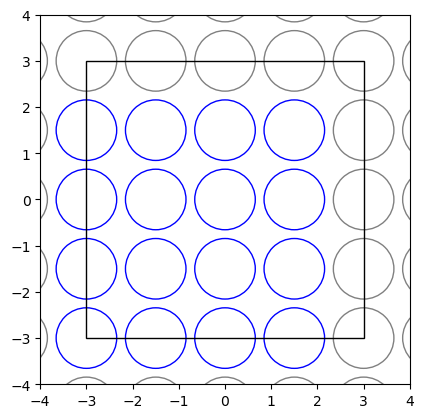

In [200]:
# simulation box
lbox = 6.0
# interaction cut off radius 
rcut = 2.0  
# temperature
tlj = 0.5
beta = 1./tlj
# MC parameters
tau = 0.1  # step size in LJ units
nsweep = 40000 # number of sweeps/passes
f_gcmc = 100
mu = 0.5 

# initalizing simulation
pos = cubic_lattice(4, lbox)
pe_tot = tot_pe(pos,rcut,lbox)

all_energies = [] 
all_positions = [] 
all_Ntot = []
# save initial state in arrays
all_energies.append(pe_tot)
all_positions.append(np.copy(pos))
print(len(pos),pe_tot)
all_Ntot.append(len(pos))

fig, ax = plt.subplots()
ax.scatter(all_positions[0][:,0],all_positions[0][:,1],
           facecolor='none',edgecolors='blue',s=1900)

# plot images 
for i in [[lbox,0],[-lbox,0],[0,lbox],[0,-lbox],
          [-lbox,-lbox],[lbox,lbox],
          [-lbox,lbox],[lbox,-lbox]]:
    ax.scatter(all_positions[0][:,0]+i[0],all_positions[0][:,1]+i[1],
               facecolor='none',edgecolors='grey',s=1900)


ax.set_xlim(-lbox/2.-1,lbox/2.+1)
ax.set_ylim(-lbox/2.-1,lbox/2.+1)
ax.set_aspect('equal')
rect = Rectangle((-lbox/2, -lbox/2), lbox, lbox, 
                 edgecolor='black',fill=False)

# Add the rectangle to the axes
ax.add_patch(rect)
plt.show()

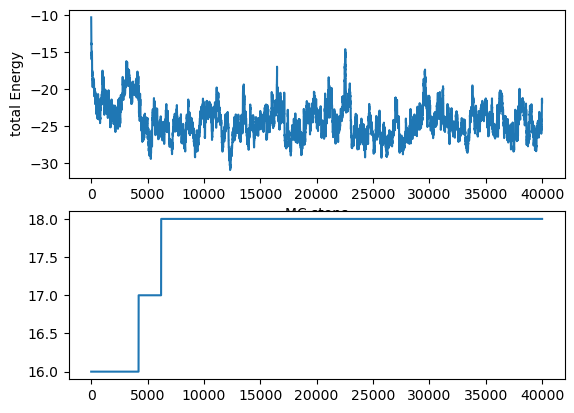

In [201]:
for i in range(nsweep):
  # attempt move 
  de = mc_move(pos, lbox, rcut, beta, tau)
  pe_tot += de
  if i%f_gcmc==0:
      de,pos = gcmc_move(pos,lbox,rcut,beta,mu)
      pe_tot += de
  # save current state 
  all_energies.append(pe_tot)
  all_positions.append(np.copy(pos))
  all_Ntot.append(len(np.copy(pos)))

fig, ax = plt.subplots(2,1) 
ax[0].plot(all_energies) 
ax[1].plot(all_Ntot) 
ax[0].set_xlabel('MC steps')
ax[0].set_ylabel('total Energy')
plt.show()

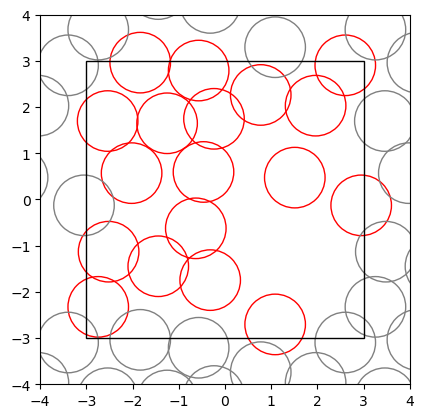

In [202]:
fig, ax = plt.subplots()
ax.scatter(all_positions[-1][:,0],all_positions[-1][:,1],
           facecolor='none',edgecolors='red',s=1900)

# plot images 
for i in [[lbox,0],[-lbox,0],[0,lbox],[0,-lbox],
          [-lbox,-lbox],[lbox,lbox],
          [-lbox,lbox],[lbox,-lbox]]:
    ax.scatter(all_positions[-1][:,0]+i[0],all_positions[-1][:,1]+i[1],
               facecolor='none',edgecolors='grey',s=1900)

ax.set_xlim(-lbox/2.-1,lbox/2.+1)
ax.set_ylim(-lbox/2.-1,lbox/2.+1)
ax.set_aspect('equal')
rect = Rectangle((-lbox/2, -lbox/2), lbox, lbox, 
                 edgecolor='black',fill=False)

# Add the rectangle to the axes
ax.add_patch(rect)
plt.show()